###Exploratory Data Analysis

In [0]:
#Cargar Tablas Gold
df_studies = spark.table("gold.nodes_studies").toPandas()
df_interventions = spark.table("gold.nodes_interventions").toPandas()
df_rels_interv = spark.table("gold.rels_study_intervention").toPandas()
df_sponsors = spark.table("gold.nodes_sponsors").toPandas()
df_rels_spon = spark.table("gold.rels_study_sponsor").toPandas()
df_facilities = spark.table("gold.nodes_facilities").toPandas()
df_rels_fac = spark.table("gold.rels_study_facility").toPandas()
df_countries = spark.table("gold.nodes_countries").toPandas()
df_rels_ctry = spark.table("gold.rels_study_country").toPandas()
df_conditions = spark.table("gold.nodes_conditions").toPandas()
df_rels_cond = spark.table("gold.rels_study_condition").toPandas()


Importar librerias

In [0]:
import matplotlib.pyplot as plt
import pandas as pd

Quantity of studies by Year

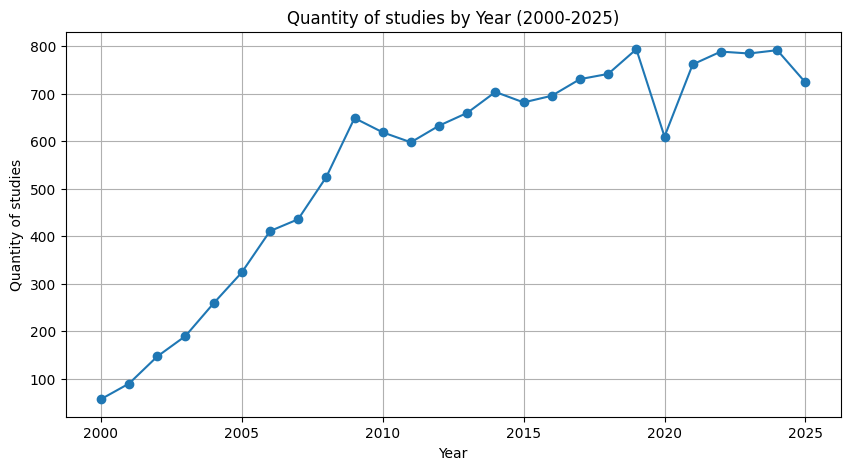

In [0]:

df = df_studies.copy()

df["start_year"] = pd.to_datetime(df["start_date"]).dt.year

df_plot = df[(df["start_year"]>=2000) & (df["start_year"]<=2025)]

counts = df_plot["start_year"].value_counts().sort_index()

plt.figure(figsize=(10,5))
plt.plot(counts.index, counts.values, marker="o")
plt.title("Quantity of studies by Year (2000-2025)")
plt.xlabel("Year")
plt.ylabel("Quantity of studies")
plt.grid(True)
plt.show()


Quantity of Studies by Phase

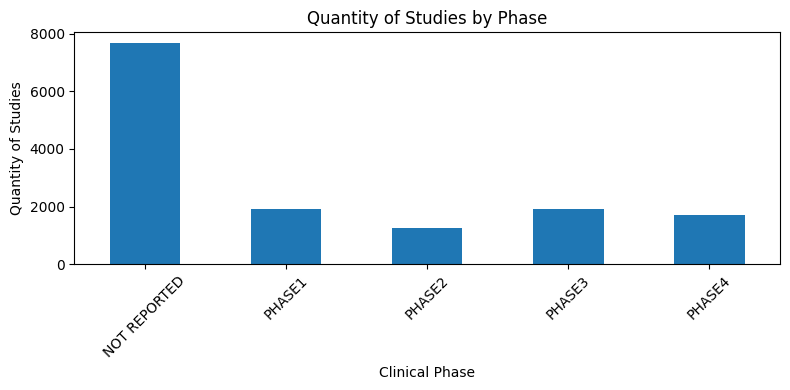

In [0]:
import matplotlib.pyplot as plt

counts = df_studies["phase"].value_counts()

orden_fases = sorted(counts.index, key=lambda x: (
    int("".join(filter(str.isdigit, x))) if any(c.isdigit() for c in x) else 0
))

plt.figure(figsize=(8,4))
counts.loc[orden_fases].plot(kind="bar")

plt.title("Quantity of Studies by Phase")
plt.xlabel("Clinical Phase")
plt.ylabel("Quantity of Studies")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Approved Dsitribution

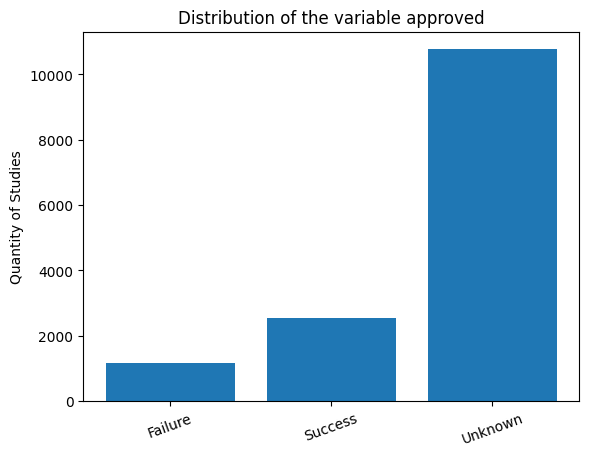

In [0]:
def map_approved(x):
    if x == 1:
        return "Success"
    elif x == 0:
        return "Failure"
    else:
        return "Unknown"

df1 = df_studies.copy()
df1["approved_label"] = df1["approved"].apply(map_approved)

counts_approved = df1["approved_label"].value_counts().sort_index()

plt.figure()
plt.bar(counts_approved.index, counts_approved.values)
plt.title("Distribution of the variable approved")
plt.ylabel("Quantity of Studies")
plt.xticks(rotation=20)
plt.show()



Distribution of the intervention type

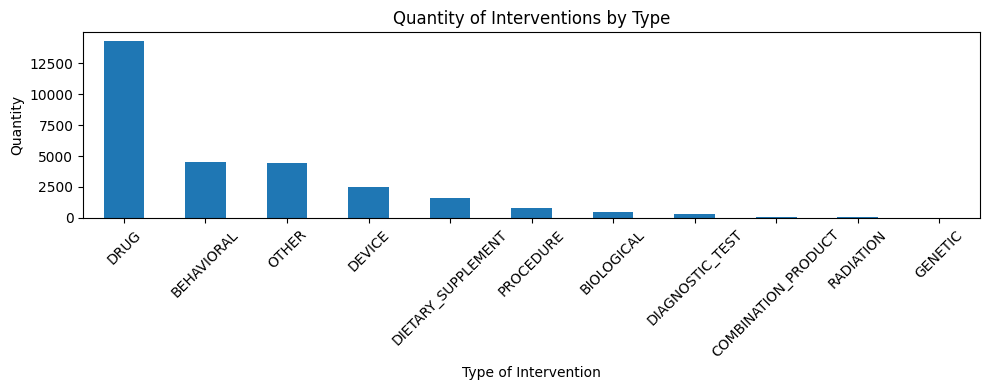

In [0]:
df_interventions["intervention_type"].value_counts().plot(kind="bar", figsize=(10,4))

plt.title("Quantity of Interventions by Type")
plt.xlabel("Type of Intervention")
plt.ylabel("Quantity")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


Sponsors by Studies

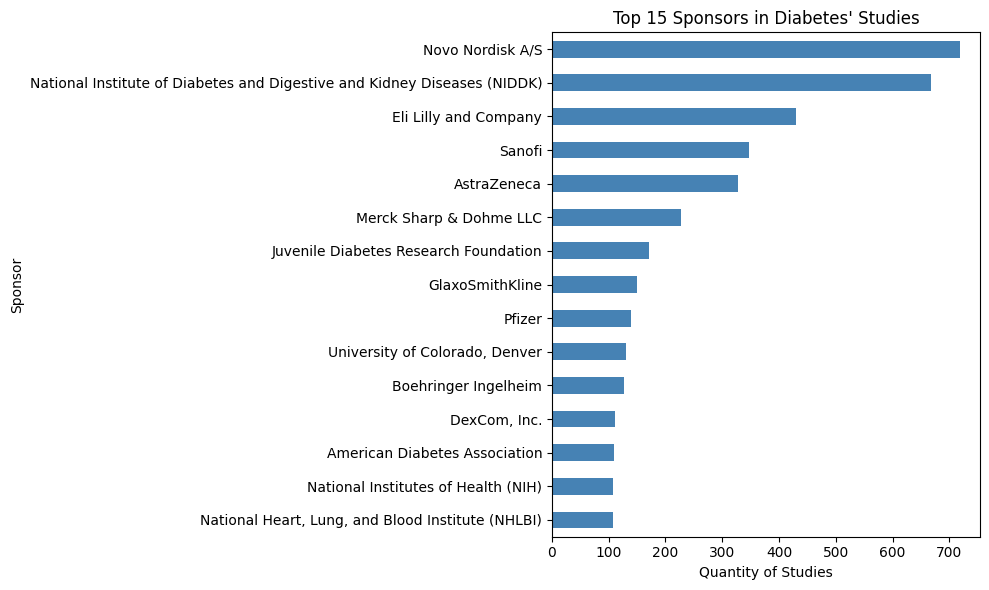

In [0]:
df_sponsors["sponsor_name"].value_counts().head(15).sort_values().plot(
    kind="barh",
    figsize=(10,6),
    color="steelblue"
)
plt.title("Top 15 Sponsors in Diabetes' Studies")
plt.xlabel("Quantity of Studies")

plt.ylabel("Sponsor")
plt.tight_layout()
plt.show()
